In [2]:
import numpy as np
from matplotlib import pyplot as plt


from sklearn.linear_model import LinearRegression
import pandas as pd

from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.rpcmci import RPCMCI
from tigramite.data_processing import DataFrame

from tigramite.independence_tests.parcorr import ParCorr


from gridsearch import RegimeAICSelector

# Real-world COVID-19 time series data

In [3]:
covid = pd.read_csv("data/COVID-19.csv", parse_dates=["date"], index_col=["date"])
covid

,cases,re,vaccinated,retail_and_recreation,grocery_and_pharmacy,parks,transit_stations,workplaces,residential
date,,,,,,,,,
2020-03-13,36,2.98,0,-3,41,-7,-16,-4,3
2020-03-14,32,2.75,0,-10,26,5,-17,0,3
2020-03-15,36,2.61,0,-10,14,44,-22,-6,4
2020-03-16,53,2.42,0,-12,27,10,-39,-31,11
2020-03-17,59,2.30,0,-29,15,2,-46,-39,15
...,...,...,...,...,...,...,...,...,...
2021-11-13,595,1.11,11138723,-2,4,30,-31,-3,3
2021-11-14,496,1.11,11147412,-3,-3,-4,-38,-7,4
2021-11-15,496,1.10,11152122,-9,1,5,-46,-31,11


<Axes: xlabel='date'>

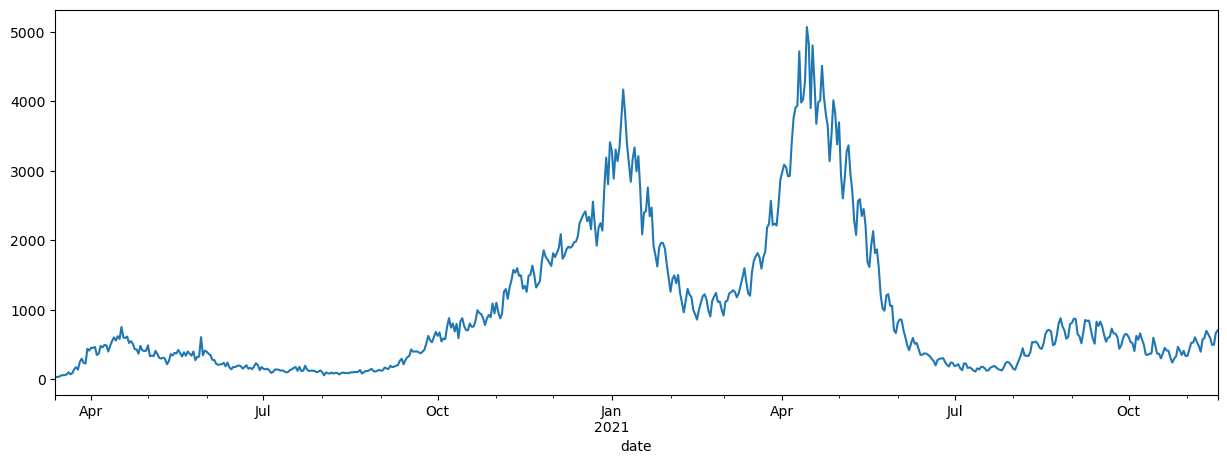

In [32]:
covid["cases"].plot(figsize=(15,5))

In [ ]:
train_data = covid[:200].values

In [35]:
selector = RegimeAICSelector(
    data=train_data, 
    tau_max=1,
    switch_thres=1e-3,
    num_iterations=15,
    max_anneal=15,
    pc_alpha=0.2,
    alpha_level=0.01,
    n_jobs=-1,
    cond_ind_test=ParCorr(),
    prediction_model=LinearRegression(),
    verbosity=-2
)

results = selector.find_best(grid_NK=range(2,3), grid_NC=range(1,6))
print("Done Grid Search for NK and NC!")

NK=2, NC=1 → AICc=113763.44, params=29
NK=2, NC=2 → AICc=117038.94, params=53
NK=2, NC=3 → AICc=105276.87, params=44
NK=2, NC=4 → AICc=105301.92, params=52
NK=2, NC=5 → AICc=105308.37, params=50
Done Grid Search for NK and NC!


In [36]:
results["best"]

{'aicc': 105276.86501173247, 'NK': 2, 'NC': 3}

In [9]:
NK = results['best']['NK']
NC = results['best']['NC']

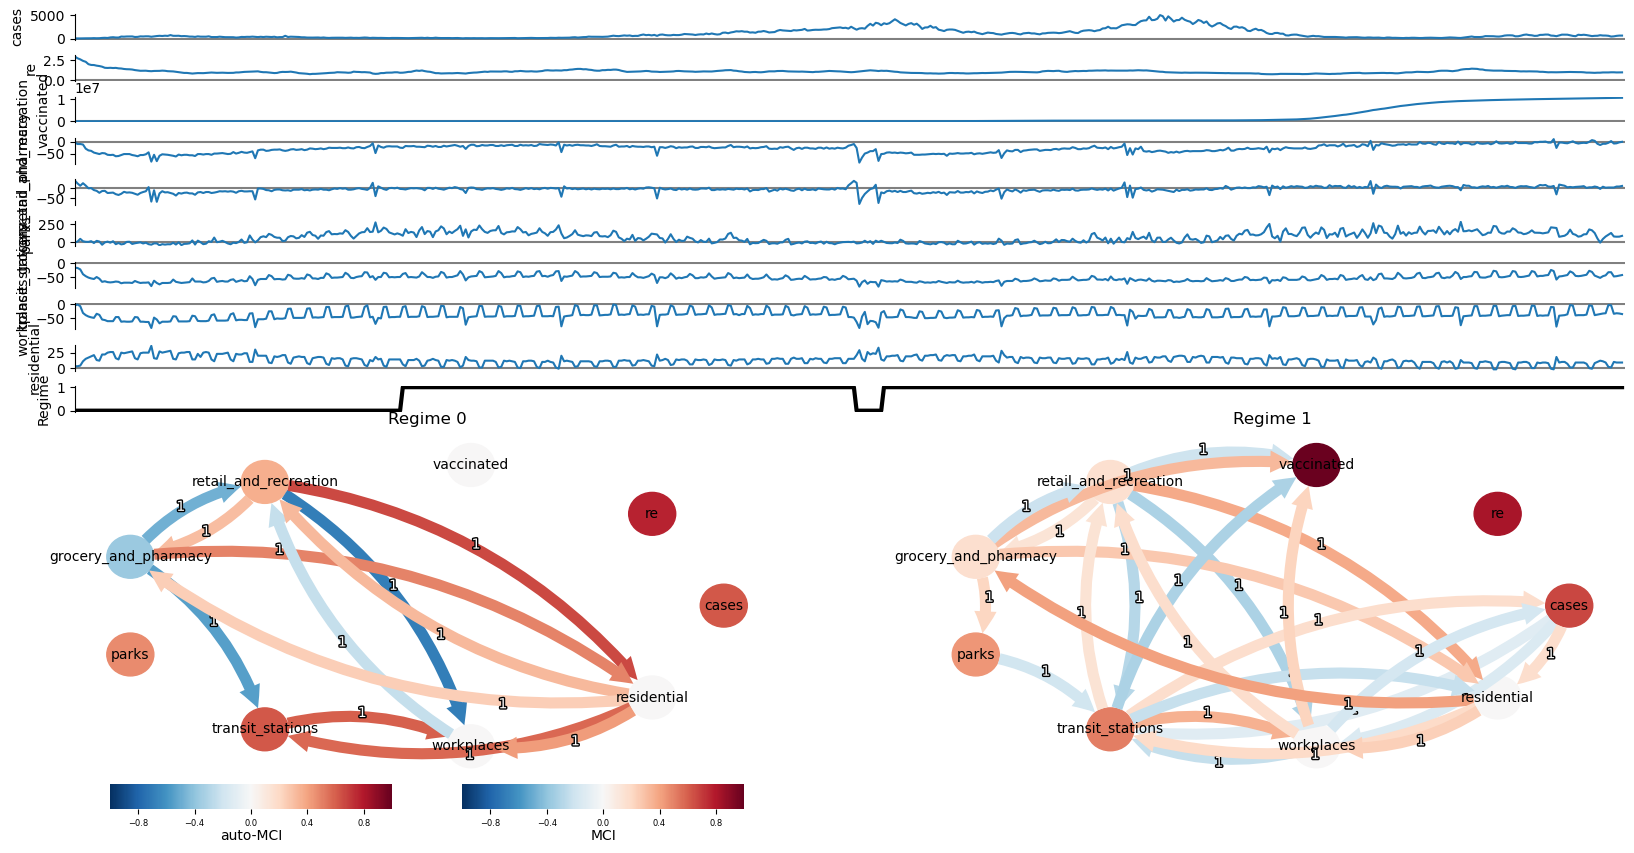

In [46]:
regimes = results['regimes'].argmax(axis=0)
n_regimes = len(results['causal_results'])


datatime = np.array([i for i in range(len(train_data))])

data = train_data
N = len(covid.columns)
var_names=covid.columns
T = len(datatime)

# Create nice Mosaic plot
mosaic = [['data %s' %j for i in range(n_regimes)] for j in range(N+1)]
for n in range(N):
    mosaic.append(['graph %s' %i for i in range(n_regimes)])

fig, axs = plt.subplot_mosaic(mosaic = mosaic, figsize=(20, 10))

for j in range(N):
    ax = axs['data %s' %j]
    ax.axhline(0., color='grey')
    ax.plot(datatime, data[:,j])
    for loc, spine in ax.spines.items():
        if loc != 'left':
            spine.set_color("none")
    
    ax.xaxis.set_ticks([])   
    ax.set_xlim(0., T)
    ax.set_ylabel(var_names[j])
    
# Regime variable
ax = axs['data %s' %N]
ax.plot(datatime, regimes.astype('int'), lw=3, color='black')
for loc, spine in ax.spines.items():
    if loc != 'left':
        spine.set_color("none")
ax.xaxis.set_ticks([]) 
ax.yaxis.set_ticks(range(n_regimes))   
ax.set_xlim(0., T)
ax.set_ylabel("Regime")
    
# Causal graphs for each regime
for w in range(n_regimes):
    if w == 0: show_colorbar=True
    else: show_colorbar = False
    tp.plot_graph(graph=results['causal_results'][w]['graph'], 
                  val_matrix=results['causal_results'][w]['val_matrix'], 
                  show_colorbar=show_colorbar,
                  var_names=covid.columns,
                  fig_ax=(fig, axs['graph %s' %w]))
    axs['graph %s' %w].set_title("Regime %d" %w, pad=-4)

fig.subplots_adjust(hspace=0.6)
plt.show()

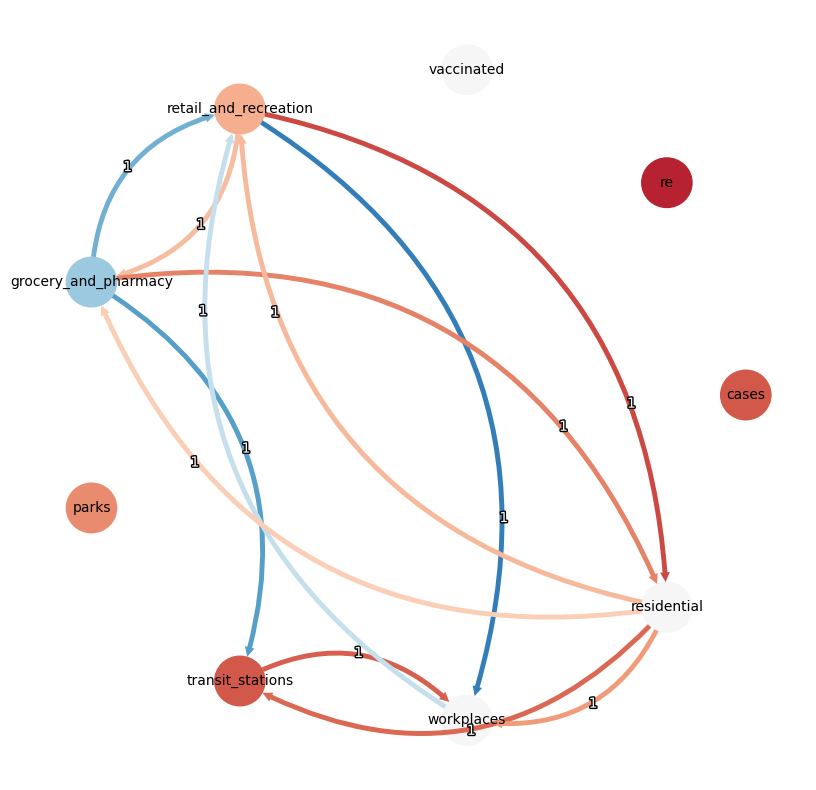

In [59]:
w = 0
tp.plot_graph(figsize=(10, 10),
              node_size=0.15,
              arrow_linewidth=3.5,
              curved_radius = 0.4,
              graph=results['causal_results'][w]['graph'], 
              val_matrix=results['causal_results'][w]['val_matrix'], 
              show_colorbar=False,
              var_names=covid.columns.to_list());

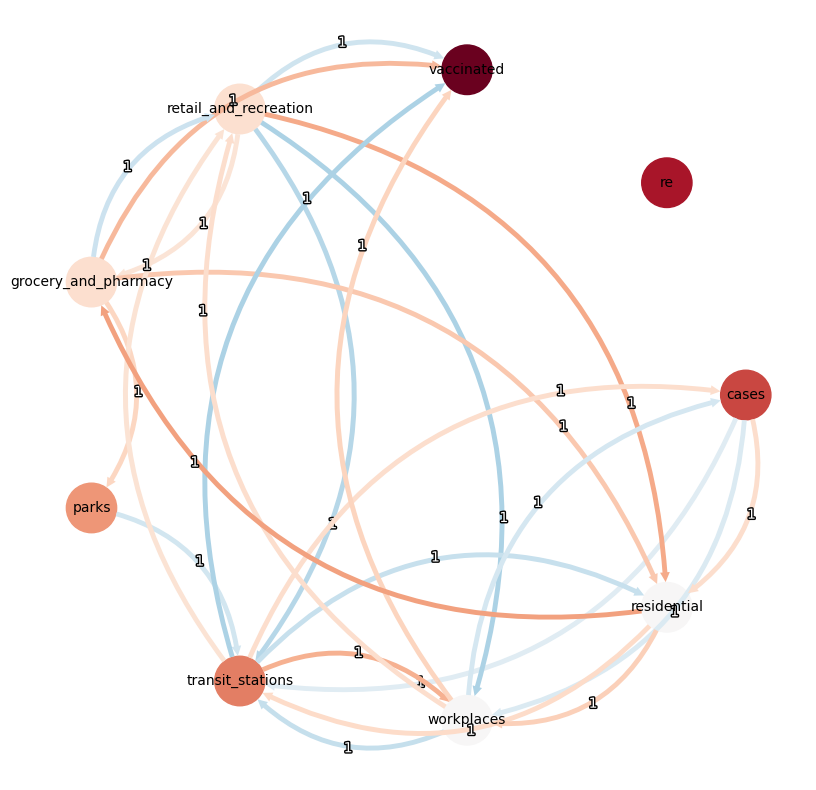

In [58]:
w = 1
tp.plot_graph(figsize=(10, 10),
              node_size=0.15,
              arrow_linewidth=3.5,
              curved_radius = 0.4,
              graph=results['causal_results'][w]['graph'], 
              val_matrix=results['causal_results'][w]['val_matrix'], 
              show_colorbar=False,
              var_names=covid.columns.to_list());

In [52]:
covid_data.to_csv("final_covid_data.csv")